# Canny Edge Detection

Today we are going to be implementing the Canny edge detection algorithm!!! It is important to note that knowing how to do the code for the first couple cells is not very important since these are just basic visualizations used in my blog. Most of these were generated using AI so I think its more important to know what you want to code and how to prompt in a way to get that. The code for the actual algorithm however I think is very critical to understand if you want to know how this algorithm works on a fundamental level. I would not skimp out on neither the math nor the code (In the notebook there will be a clear sign when we are shifting into relevent code).

www.aryanjain.work/blog/harris-corner-detection

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from scipy import ndimage

(600, 868, 3)


Text(0.5, 1.0, 'Building')

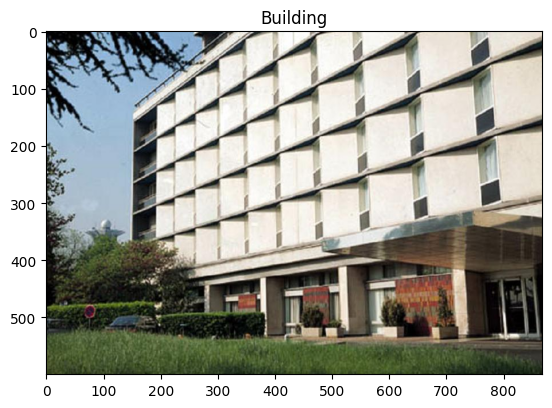

In [2]:
# Load the image we are going to be using for edge detection and display it

img = cv2.imread("../data/canny-edge-detector/building.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
print(img.shape)
plt.imshow(img)
plt.title("Building")

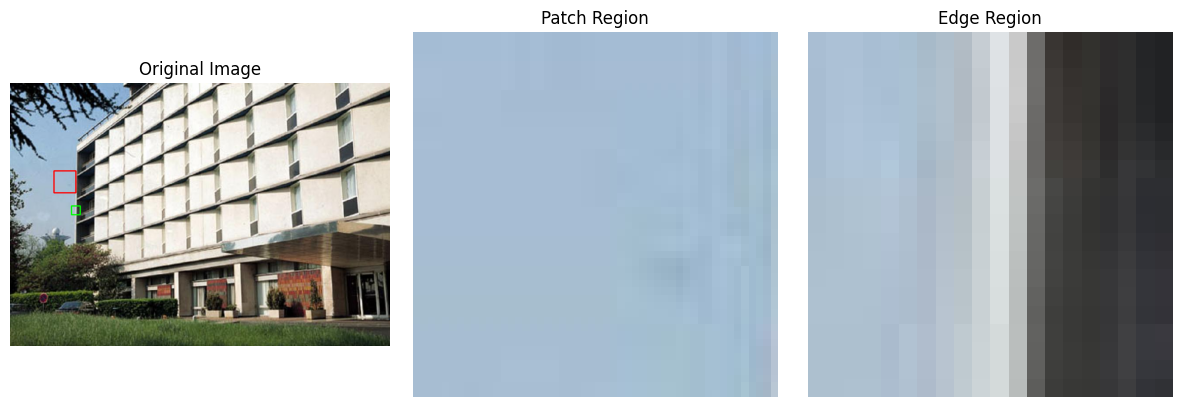

In [3]:
# Images follow this format since the y is represented by the rows: img[y,x]

patch = img[200:250, 100:150]

edge = img[280:300, 140:160]

img_boxes = img.copy()
cv2.rectangle(img_boxes, (100,200), (150,250), (255,0,0), 2)
cv2.rectangle(img_boxes, (140,280), (160,300), (0,255,0), 2)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img_boxes)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(patch)
plt.title("Patch Region")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(edge)
plt.title("Edge Region")
plt.axis("off")

plt.tight_layout()

plt.savefig("../outputs/canny-edge-detection/patch_vs_edge.png", bbox_inches="tight")

plt.show()

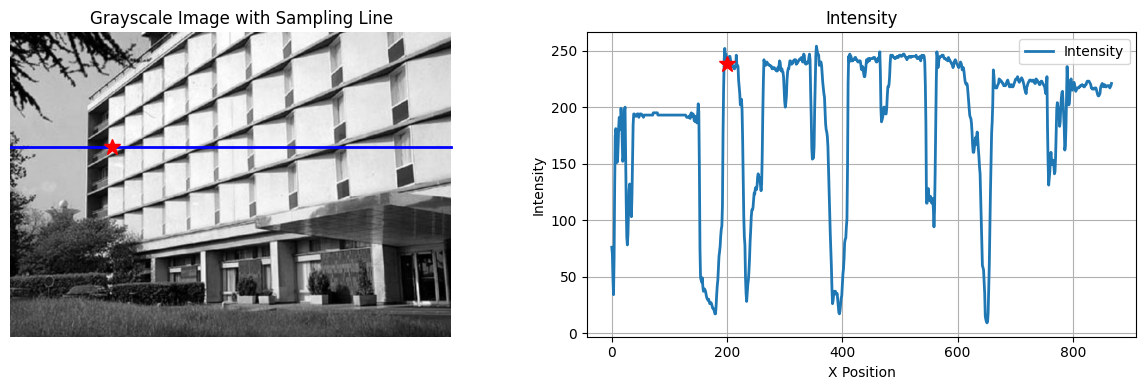

In [4]:
# Look at intensity values along a strip of pixels

gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

y = 225
x_start = 0
x_end = 868

intensities = gray_img[y, x_start:x_end]
x_vals = np.arange(x_start, x_end)

line = np.linspace(intensities[0], intensities[-1], len(intensities))

px, py = 200, 225
intensity_point = gray_img[py, px]

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0].imshow(gray_img, cmap='gray')
axs[0].plot([x_start, x_end], [y, y], color='blue', linewidth=2)
axs[0].plot(px, py, marker='*', color='red', markersize=12)
axs[0].set_title("Grayscale Image with Sampling Line")
axs[0].axis("off")

axs[1].plot(x_vals, intensities, label="Intensity", linewidth=2)

axs[1].plot(px, gray_img[y, px], marker='*', color='red', markersize=12)

axs[1].set_title(f"Intensity")
axs[1].set_xlabel("X Position")
axs[1].set_ylabel("Intensity")
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()

plt.savefig("../outputs/canny-edge-detection/intensity.png", bbox_inches="tight")

plt.show()

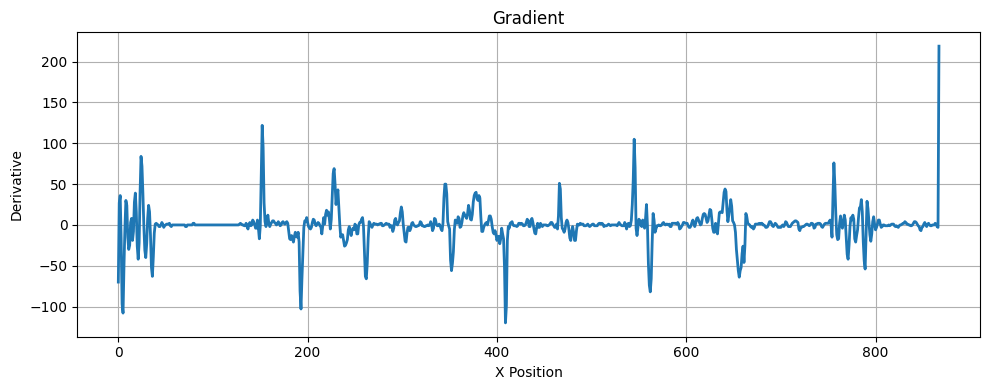

In [5]:
# Look at the gradient of intensity values along the previous strip of pixels

kernel = np.array([-1, 0, 1])

derivative = np.convolve(intensities, kernel, mode="same")

plt.figure(figsize=(10,4))
plt.plot(x_vals, derivative, linewidth=2)
plt.title("Gradient")
plt.xlabel("X Position")
plt.ylabel("Derivative")

plt.grid(True)
plt.tight_layout()
plt.savefig("../outputs/canny-edge-detection/gradient.png", bbox_inches="tight")
plt.show()

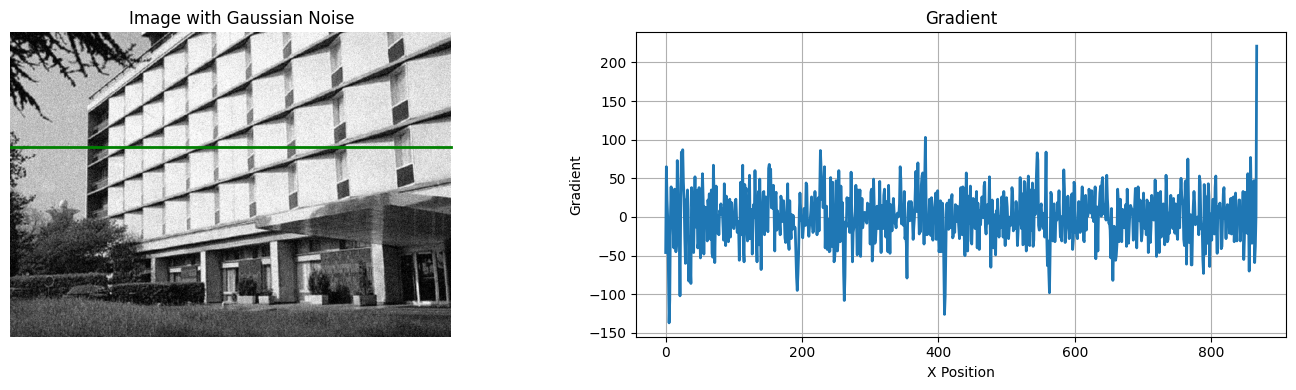

In [6]:
# Add Gaussian noise and look at what happens to the derivative

noise_sigma = 20
noise = np.random.normal(0, noise_sigma, gray_img.shape)

noisy_img = gray_img.astype(np.float32) + noise
noisy_img = np.clip(noisy_img, 0, 255).astype(np.uint8)

noisy_intensities = noisy_img[y, x_start:x_end]

kernel = np.array([-1, 0, 1])
gradient = np.convolve(noisy_intensities, kernel, mode="same")

fig, axs = plt.subplots(1, 2, figsize=(14,4))

# Noisy image
axs[0].imshow(noisy_img, cmap="gray")
axs[0].plot([x_start, x_end], [y, y], color="green", linewidth=2)
axs[0].set_title("Image with Gaussian Noise")
axs[0].axis("off")

# Gradient plot
axs[1].plot(x_vals, gradient, linewidth=2)
axs[1].set_title(f"Gradient")
axs[1].set_xlabel("X Position")
axs[1].set_ylabel("Gradient")
axs[1].grid(True)

plt.tight_layout()
plt.savefig("../outputs/canny-edge-detection/noisy_gradient.png", bbox_inches="tight")
plt.show()

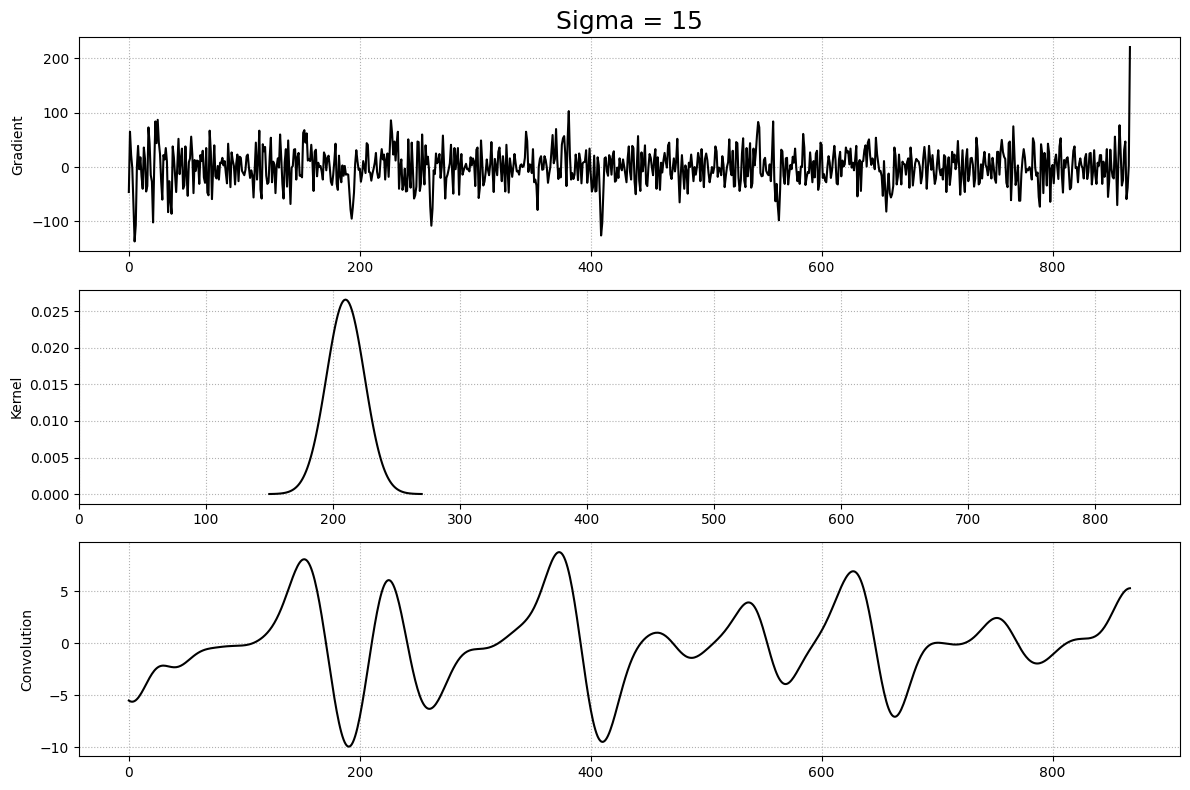

In [7]:
# Applying a Gaussian kernal to the gradient signal

# gradient is from the previous cell

sigma = 15
radius = int(4 * sigma)
k = np.arange(-radius, radius + 1)
gaussian = np.exp(-(k**2) / (2 * sigma**2))
gaussian = gaussian / gaussian.sum()

smoothed_gradient = np.convolve(gradient, gaussian, mode="same")

fig, axs = plt.subplots(3, 1, figsize=(12, 8))

axs[0].plot(x_vals, gradient, color="black", linewidth=1.5)
axs[0].set_title(f"Sigma = {sigma}", fontsize=18)
axs[0].set_ylabel("Gradient")
axs[0].grid(True, linestyle=":")

kernel_offset = 150
axs[1].plot(kernel_offset + np.arange(len(gaussian)), gaussian, color="black", linewidth=1.5)
axs[1].set_ylabel("Kernel")
axs[1].grid(True, linestyle=":")
axs[1].set_xlim(x_vals[0], x_vals[-1])

axs[2].plot(x_vals, smoothed_gradient, color="black", linewidth=1.5)
axs[2].set_ylabel("Convolution")
axs[2].grid(True, linestyle=":")

plt.tight_layout()
plt.savefig("../outputs/canny-edge-detection/gaussian_gradient_smoothing.png", bbox_inches="tight")
plt.show()

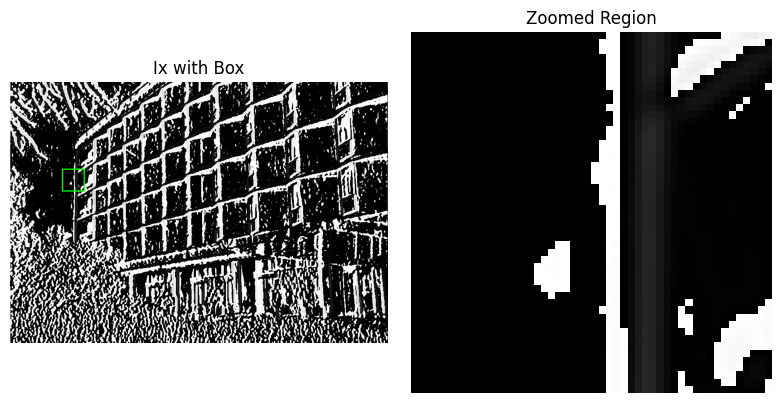

In [8]:
# We are going to be zooming into the Ix gradient to illustrate how in NMS we are thinning out edges as opposed to erasing them 

smooth_window_size = 7
blur = cv2.GaussianBlur(gray_img, (smooth_window_size, smooth_window_size), 0)
kernel = np.array([-1, 0, 1], dtype=np.float32) / 2.0
Ix = ndimage.convolve1d(blur, kernel, axis=1, mode='constant')

Ix_norm = (Ix - Ix.min()) / (Ix.max() - Ix.min())
Ix_norm = (Ix_norm * 255).astype(np.uint8)

Ix_rgb = cv2.cvtColor(Ix_norm, cv2.COLOR_GRAY2RGB)

Ix_box = Ix_rgb.copy()

x1, x2, y1, y2 = 120, 170, 200, 250
cv2.rectangle(Ix_box, (x1, y1), (x2, y2), (0, 255, 0), 2)

zoom_region = Ix_norm[y1:y2, x1:x2]

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(Ix_box)
plt.title("Ix with Box")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(zoom_region, cmap="gray")
plt.title("Zoomed Region")
plt.axis("off")

plt.tight_layout()
plt.savefig("../outputs/canny-edge-detection/ix_thinning.png", bbox_inches="tight")
plt.show()

# Canny Edge Detection Algorithm Code

Now that we have analyzed the data lets begin actually coding out the algorithm. I will reinitalize the packages and variables so you can start reading from here down without confusion (think of this like two notebooks in one)!

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from scipy import ndimage

Text(0.5, 1.0, 'Building')

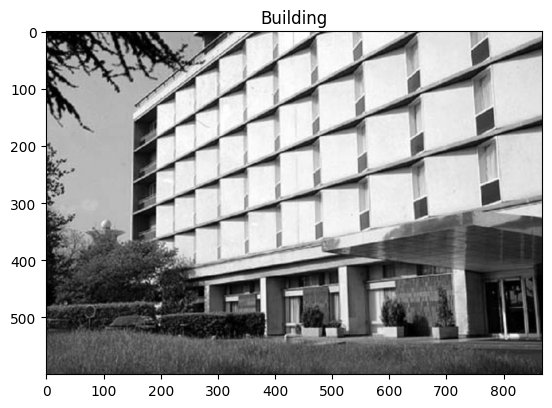

In [10]:
img = cv2.imread("../data/canny-edge-detector/building.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(img, cmap = "gray")
plt.title("Building")

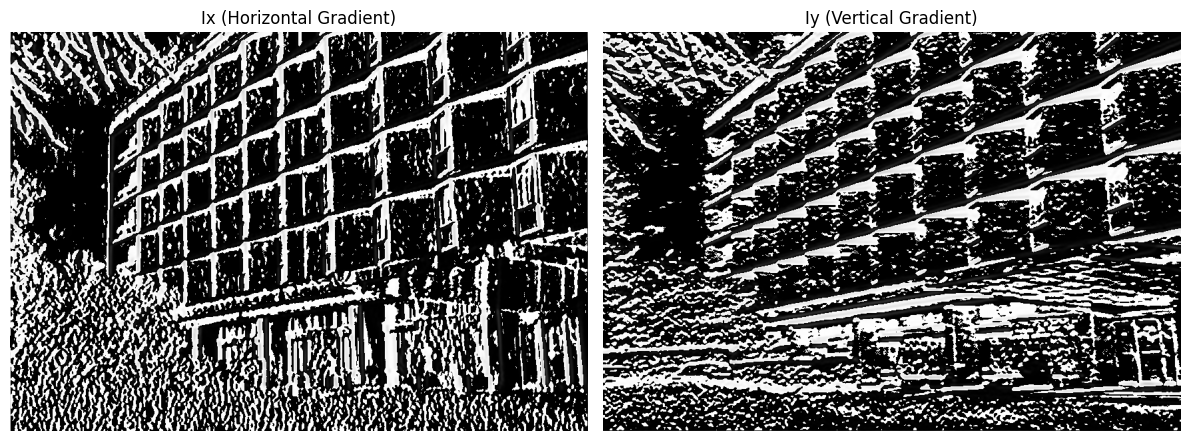

In [11]:
# We will now do the DoG

# Recall the first step is performing a Gaussian Blur
smooth_window_size = 7
blur = cv2.GaussianBlur(img, (smooth_window_size, smooth_window_size), 0)

# We can now create a Kernal and pass it through the image
kernel = np.array([-1, 0, 1], dtype=np.float32) / 2.0
Ix = ndimage.convolve1d(blur, kernel, axis=1, mode='constant')
Iy = ndimage.convolve1d(blur, kernel, axis=0, mode='constant')

# We have successfully computed the gradients and now we display the two
fig, axs = plt.subplots(1, 2, figsize=(12,5))

axs[0].imshow(Ix, cmap="gray")
axs[0].set_title("Ix (Horizontal Gradient)")
axs[0].axis("off")

axs[1].imshow(Iy, cmap="gray")
axs[1].set_title("Iy (Vertical Gradient)")
axs[1].axis("off")

plt.tight_layout()
plt.savefig("../outputs/canny-edge-detection/ix_iy.png", bbox_inches="tight")
plt.show()

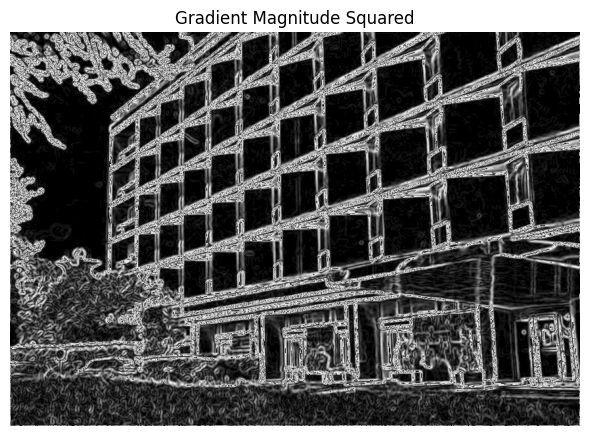

In [12]:
# We now can combine them and this will give us all the edges in the image
grad_mag = np.sqrt(np.square(Ix) + np.square(Iy))

plt.figure(figsize=(6,5))
plt.imshow(grad_mag, cmap="gray")
plt.title("Gradient Magnitude Squared")
plt.axis("off")

plt.tight_layout()
plt.savefig("../outputs/canny-edge-detection/gradient_magnitude.png", bbox_inches="tight")
plt.show()

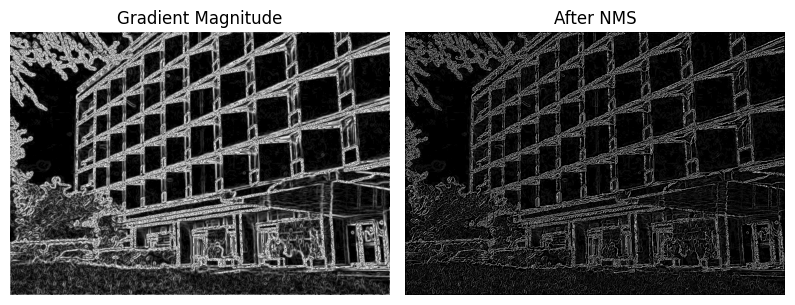

In [27]:
# Doing NMS from scratch

# We already have the gradients combined and now we can take those and compute the angle using arctan2 and rad2deg
angle = np.rad2deg(np.arctan2(Iy,Ix))

# np.rad2deg() gives us angles from -180 to 180. Edges don’t care about direction vs opposite direction. 
# A 45 degree edge and a 225 degree edge are the same edge. Therefore we add 180 and divide by 180. 
angle = (angle + 180) % 180

# q is the quantized array and we will use masks to apply the correct bins to each angle
q = np.zeros_like(angle)

mask = (angle >= 22.5) & (angle < 67.5)
q[mask] = 45

mask = (angle >= 67.5) & (angle < 112.5)
q[mask] = 90

mask = (angle >= 112.5) & (angle < 157.5)
q[mask] = 135

nms = np.zeros_like(grad_mag)
H,W = nms.shape

# we are chopping off the first and last values so we don't go out of bounds
for y in range(1,H-1):
    for x in range(1,W-1):
        current_grad = grad_mag[y,x]
        direction = q[y,x]

        if direction == 0:
            # this means we are going left to right
            # p stands for pixel
            p1 = grad_mag[y,x-1]
            p2 = grad_mag[y,x+1]
        elif direction == 45:
            # the angle is 45 degrees so we need the top left and bottom right neighboring pixel
            p1 = grad_mag[y-1,x-1]
            p2 = grad_mag[y+1,x+1]
        elif direction == 90:
            # we are going up down
            p1 = grad_mag[y-1,x]
            p2 = grad_mag[y+1,x]
        else:
            # the angle is 135 so we need top right and bottom left
            p1 = grad_mag[y-1,x+1]
            p2 = grad_mag[y+1,x-1]
        if current_grad >= p1 and current_grad >= p2:
            nms[y,x] = current_grad

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(grad_mag, cmap="gray")
plt.title("Gradient Magnitude")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(nms, cmap="gray")
plt.title("After NMS")
plt.axis("off")

plt.tight_layout()
plt.savefig("../outputs/canny-edge-detection/post_nms.png", bbox_inches="tight")
plt.show()

In [68]:
# we will now move into the final part of this algorithm: hysteresis thresholding

# abitrary values for these (except the strong)
high_thresh = 0.675 * nms.max()
low_thresh = 0.2 * nms.max()

strong = 255
weak = 125

res = np.zeros_like(nms,dtype = np.uint8)

strong_y, strong_x = np.where(nms >= high_thresh)
weak_y, weak_x = np.where((nms < high_thresh)& (nms >= low_thresh))
res[strong_y, strong_x] = strong
res[weak_y, weak_x] = weak

# Now we do the 8-neighbor check
H, W = res.shape
for y in range(1,H-1):
    for x in range(1,W-1):
        if res[y,x] == weak:
            if (res[y-1,x] == strong or res[y+1,x] == strong or res[y,x-1] == strong or res[y,x+1] == strong or
                res[y-1,x-1] == strong or res[y-1,x+1] == strong or res[y+1,x-1] == strong or res[y+1,x+1] == strong):
                res[y,x] = strong
            else:
                res[y,x] = 0            

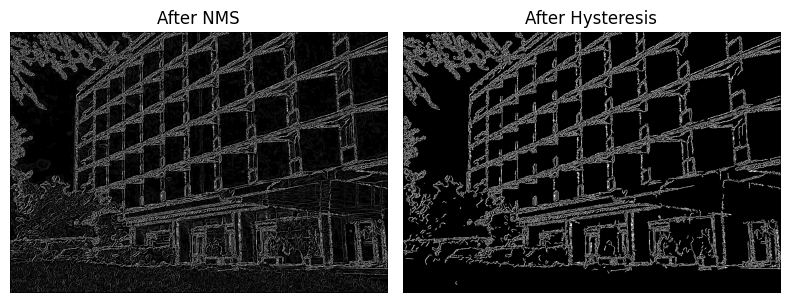

In [69]:
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(nms, cmap="gray")
plt.title("After NMS")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(res, cmap="gray")
plt.title("After Hysteresis")
plt.axis("off")

plt.tight_layout()
plt.savefig("../outputs/canny-edge-detection/post_hysteresis.png", bbox_inches="tight")
plt.show()

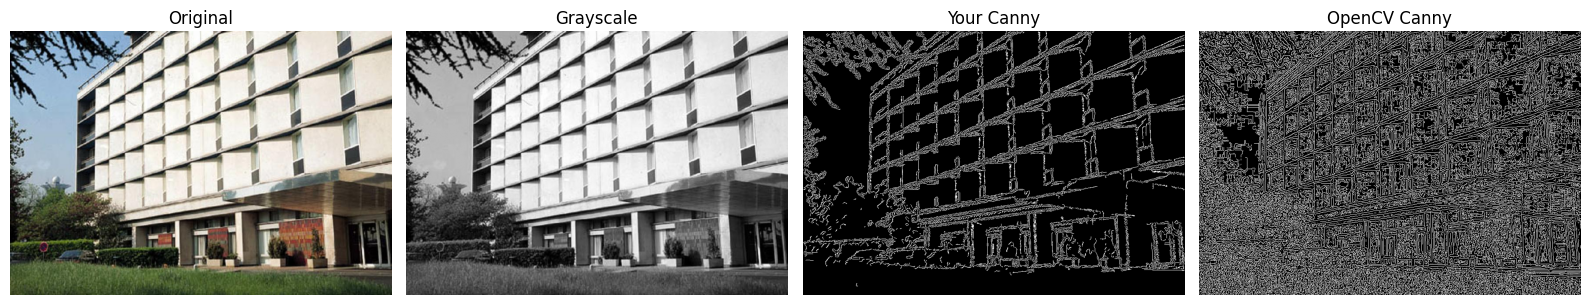

In [74]:
# original color
img_color = cv2.imread("../data/canny-edge-detector/building.jpg")
img_color = cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB)

# grayscale (you already have this, but keeping consistent)
img_gray = cv2.cvtColor(img_color, cv2.COLOR_RGB2GRAY)

# OpenCV Canny (use same thresholds for fairness)
canny_cv = cv2.Canny(img_gray, int(low_thresh), int(high_thresh))

plt.figure(figsize=(16, 4))

# original
plt.subplot(1, 4, 1)
plt.imshow(img_color)
plt.title("Original")
plt.axis("off")

# grayscale
plt.subplot(1, 4, 2)
plt.imshow(img_gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

# your implementation
plt.subplot(1, 4, 3)
plt.imshow(res, cmap="gray")
plt.title("Your Canny")
plt.axis("off")

# OpenCV Canny
plt.subplot(1, 4, 4)
plt.imshow(canny_cv, cmap="gray")
plt.title("OpenCV Canny")
plt.axis("off")

plt.tight_layout()
plt.savefig("../outputs/canny-edge-detection/final.png", bbox_inches="tight")
plt.show()